In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import yfinance as yf


# =========================
# Reproducibility
# =========================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("SEED:", SEED)

DEVICE: cpu
SEED: 42


In [2]:
# Config dữ liệu + model dims
# Data config
TICKERS = [
    "AAPL", "ADBE", "AMD", "CMCSA", "COST",
    "INTC", "INTU", "MSFT", "QCOM", "SBUX"
]

START_DATE = "2005-01-01"
END_DATE   = "2024-01-01"

FEATURE_COLS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

TARGET_COL = "Close"
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

LOOKBACK = 21
DIRECTION_EPS = 0.0

# model dims
LSTM_HIDDEN = 64
GNN_HIDDEN = 16
MLP_HIDDEN = 64
DROPOUT = 0.5 #Bài báo yêu cầu 0.5

print("TICKERS:", TICKERS)
print("FEATURE_COLS:", FEATURE_COLS)
print("LOOKBACK:", LOOKBACK)

TICKERS: ['AAPL', 'ADBE', 'AMD', 'CMCSA', 'COST', 'INTC', 'INTU', 'MSFT', 'QCOM', 'SBUX']
FEATURE_COLS: ['Open', 'High', 'Low', 'Close', 'Volume']
LOOKBACK: 21


In [3]:
# Tải và làm sạch dữ liệu
def download_one_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    # Tải dữ liệu với auto_adjust=True để lấy giá đã điều chỉnh (Adjusted Price)
    # Điều này cực kỳ quan trọng để tính toán lợi nhuận (Return) chính xác khi có chia tách/cổ tức
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=True, # Đổi thành True để OHLC là giá đã điều chỉnh
        progress=False,
        threads=False
    )

    if df.empty:
        raise ValueError(f"Không tải được dữ liệu cho {ticker}")

    # Xử lý MultiIndex nếu yfinance trả về cấu trúc phân cấp
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]

    # Tính toán lợi nhuận ngày (Daily Return)
    # Cột này bắt buộc phải có để GNN tính ma trận tương quan Pearson
    df["Return"] = df["Close"].pct_change()

    # Giữ lại 5 đặc trưng cơ bản + Return
    keep_cols = ["Open", "High", "Low", "Close", "Volume", "Return"]
    df = df[[c for c in keep_cols if c in df.columns]].copy()

    # Xử lý dữ liệu khuyết thiếu
    # Dòng đầu tiên của Return luôn là NaN, cần fill bằng 0.0
    df = df.ffill().fillna(0.0)
    
    df.index = pd.to_datetime(df.index)
    return df


data_dict = {}
for ticker in TICKERS:
    data_dict[ticker] = download_one_ticker(ticker, START_DATE, END_DATE)

# Giao ngày giữa tất cả mã
common_index = None
for ticker in TICKERS:
    idx = data_dict[ticker].index
    common_index = idx if common_index is None else common_index.intersection(idx)

common_index = common_index.sort_values()

for ticker in TICKERS:
    data_dict[ticker] = data_dict[ticker].loc[common_index].copy()

print("Số ngày chung:", len(common_index))
print("Ngày đầu:", common_index.min())
print("Ngày cuối:", common_index.max())

for ticker in TICKERS[:3]:
    print(ticker, data_dict[ticker].shape)
    print(data_dict[ticker].head(2))
    print()

Số ngày chung: 4781
Ngày đầu: 2005-01-03 00:00:00
Ngày cuối: 2023-12-29 00:00:00
AAPL (4781, 6)
                Open      High       Low     Close      Volume   Return
Date                                                                   
2005-01-03  0.970502  0.975446  0.937842  0.948180   691992000  0.00000
2005-01-04  0.955670  0.980839  0.943385  0.957917  1096810400  0.01027

ADBE (4781, 6)
                 Open       High        Low      Close   Volume    Return
Date                                                                     
2005-01-03  31.493821  31.743772  30.768963  30.838949  5508800  0.000000
2005-01-04  31.098899  31.183883  29.674179  30.024111  7515400 -0.026422

AMD (4781, 6)
                 Open       High        Low      Close    Volume    Return
Date                                                                      
2005-01-03  22.110001  22.299999  21.250000  21.410000   9275300  0.000000
2005-01-04  21.480000  21.510000  20.209999  20.209999  20375800

In [4]:
# Cài đặt tensor đầu vào
def build_feature_tensor(data_dict: Dict[str, pd.DataFrame],
                         tickers: List[str],
                         feature_cols: List[str]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, pd.DatetimeIndex]:
    dates = data_dict[tickers[0]].index

    T = len(dates)
    N = len(tickers)
    F = len(feature_cols)

    features_3d = np.zeros((T, N, F), dtype=np.float32)
    close_2d = np.zeros((T, N), dtype=np.float32)
    return_2d = np.zeros((T, N), dtype=np.float32)

    for j, ticker in enumerate(tickers):
        df = data_dict[ticker]

        features_3d[:, j, :] = df[feature_cols].values.astype(np.float32)
        close_2d[:, j] = df["Close"].values.astype(np.float32)
        return_2d[:, j] = df["Return"].values.astype(np.float32)

    return features_3d, close_2d, return_2d, dates


features_3d, close_2d, return_2d, dates = build_feature_tensor(
    data_dict=data_dict,
    tickers=TICKERS,
    feature_cols=FEATURE_COLS
)

print("features_3d:", features_3d.shape)
print("close_2d:", close_2d.shape)
print("return_2d:", return_2d.shape)
print("dates:", len(dates))

features_3d: (4781, 10, 5)
close_2d: (4781, 10)
return_2d: (4781, 10)
dates: 4781


In [5]:
# Utility functions
def normalize_adjacency(adj: np.ndarray) -> np.ndarray:
    """
    Symmetric normalization: D^{-1/2} A D^{-1/2}
    adj: [N, N]
    """
    adj = adj.astype(np.float32)
    deg = adj.sum(axis=1)
    deg_inv_sqrt = np.power(np.maximum(deg, 1e-8), -0.5)
    D_inv_sqrt = np.diag(deg_inv_sqrt)
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt
    return adj_norm.astype(np.float32)


def compute_metrics(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    last_close: np.ndarray,
                    eps: float = 0.0):
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred.reshape(-1)
    last_f = last_close.reshape(-1)

    mse = mean_squared_error(y_true_f, y_pred_f)
    mae = mean_absolute_error(y_true_f, y_pred_f)
    rmse = float(np.sqrt(mse))

    true_up = (y_true_f - last_f) > eps
    pred_up = (y_pred_f - last_f) > eps
    directional_accuracy = float((true_up == pred_up).mean())

    return {
        "MSE": float(mse),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Directional_Accuracy": directional_accuracy
    }

In [6]:
# Dataset
class StockGraphDataset(Dataset):
    def __init__(self, X_seq, X_node, A, y_res, y_close, last_close):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_node = torch.tensor(X_node, dtype=torch.float32)
        self.A = torch.tensor(A, dtype=torch.float32)
        self.y_res = torch.tensor(y_res, dtype=torch.float32)
        self.y_close = torch.tensor(y_close, dtype=torch.float32)
        self.last_close = torch.tensor(last_close, dtype=torch.float32)

    def __len__(self):
        return len(self.y_close)

    def __getitem__(self, idx):
        return (
            self.X_seq[idx],
            self.X_node[idx],
            self.A[idx],
            self.y_res[idx],
            self.y_close[idx],
            self.last_close[idx]
        )

In [7]:
# Base models
class SimpleGCNLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """
        x:   [B, N, F]
        adj: [B, N, N]
        """
        h = self.linear(x)
        out = torch.bmm(adj, h)
        return out

class LSTMOnlyModel(nn.Module):
    def __init__(self, input_dim=5, lstm_hidden=64, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=lstm_hidden, 
                            num_layers=2, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, seq, node_x, adj, last_close):
        B, N, T, F = seq.shape
        seq_flat = seq.reshape(B * N, T, F)

        _, (h_n, _) = self.lstm(seq_flat)
        h = h_n[-1] # Lấy hidden state cuối
        h = self.dropout(h)

        # Chữa logic: Dự báo giá trực tiếp, không cộng last_close
        pred_price = self.fc(h).reshape(B, N) 
        return pred_price

In [8]:
# Train / eval / predict helpers
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in train_one_epoch.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        optimizer.zero_grad()
        pred_close = model(seq, node_x, adj, last_close)
        loss = criterion(pred_close, y_close)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in evaluate_loss.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        y_close = y_close.to(device)
        last_close = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close)
        loss = criterion(pred_close, y_close)
        total_loss += loss.item() * y_close.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()

    preds = []
    trues = []
    lasts = []

    for batch in loader:
        if len(batch) == 6:
            seq, node_x, adj, y_res, y_close, last_close = batch
        elif len(batch) == 5:
            seq, node_x, adj, y_close, last_close = batch
        else:
            raise ValueError("Unexpected batch format in predict_model.")

        seq = seq.to(device)
        node_x = node_x.to(device)
        adj = adj.to(device)
        last_close_device = last_close.to(device)

        pred_close = model(seq, node_x, adj, last_close_device)

        preds.append(pred_close.cpu().numpy())
        trues.append(y_close.numpy())
        lasts.append(last_close.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    lasts = np.concatenate(lasts, axis=0)

    return preds, trues, lasts


def fit_model_silent(model, train_loader, val_loader, epochs, lr, patience, device, verbose=False):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_state = None
    best_val = float("inf")
    wait = 0

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose:
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, history

In [9]:
# CELL 10 — Config expanding + graph
# Paper-faithful expanding config
EXP_WARM_START = True
EXP_TEST_DAYS = 50
EXP_INITIAL_TRAIN_DAYS = 252 * 2
EXP_VAL_DAYS = 50

EXP_BATCH_SIZE = 11

EXP_USE_FAST_MODE = False #Thử nghiệm dùng 40-50 Epoch như bài báo của tác giả

EXP_FAST_INIT_EPOCHS = 20
EXP_FAST_UPDATE_EPOCHS = 6
EXP_FAST_PATIENCE = 5

EXP_FINAL_INIT_EPOCHS = 100
EXP_FINAL_UPDATE_EPOCHS = 15
EXP_FINAL_PATIENCE = 5

EXP_INIT_EPOCHS = EXP_FAST_INIT_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_INIT_EPOCHS
EXP_UPDATE_EPOCHS = EXP_FAST_UPDATE_EPOCHS if EXP_USE_FAST_MODE else EXP_FINAL_UPDATE_EPOCHS
EXP_PATIENCE = EXP_FAST_PATIENCE if EXP_USE_FAST_MODE else EXP_FINAL_PATIENCE

EXP_LR_LSTM = 0.005
EXP_LR_HYBRID = 0.005

# Pearson graph
EXP_GRAPH_RECENT_DAYS = 252 * 2
EXP_PEARSON_THRESHOLD = 0.85
EXP_PEARSON_TOPK = 5

# Manual association-style graph
EXP_ASSOC_RECENT_DAYS = 252 * 2
EXP_ASSOC_MIN_SUPPORT = 0.05
EXP_ASSOC_MIN_CONFIDENCE = 0.10
EXP_ASSOC_LIFT_THRESHOLD = 1.7
EXP_ASSOC_TOPK = 3
EXP_ASSOC_EDGE_WEIGHT = 0.50

# merged graph
EXP_FINAL_GRAPH_TOPK = 5

print("EXP_USE_FAST_MODE:", EXP_USE_FAST_MODE)
print("EXP_INIT_EPOCHS:", EXP_INIT_EPOCHS)
print("EXP_UPDATE_EPOCHS:", EXP_UPDATE_EPOCHS)
print("EXP_BATCH_SIZE:", EXP_BATCH_SIZE)
print("EXP_LR_LSTM:", EXP_LR_LSTM)
print("EXP_LR_HYBRID:", EXP_LR_HYBRID)
print("EXP_PEARSON_THRESHOLD:", EXP_PEARSON_THRESHOLD)
print("EXP_ASSOC_LIFT_THRESHOLD:", EXP_ASSOC_LIFT_THRESHOLD)

EXP_USE_FAST_MODE: False
EXP_INIT_EPOCHS: 100
EXP_UPDATE_EPOCHS: 15
EXP_BATCH_SIZE: 11
EXP_LR_LSTM: 0.005
EXP_LR_HYBRID: 0.005
EXP_PEARSON_THRESHOLD: 0.85
EXP_ASSOC_LIFT_THRESHOLD: 1.7


In [10]:
# Leakage-safe scaling cho expanding
def fit_and_scale_for_expanding_initial_window(raw_features_3d, first_test_t, initial_train_days):
    T, N, F = raw_features_3d.shape

    train_start_t = max(0, first_test_t - initial_train_days)
    train_end_t = first_test_t - 1

    scaled = np.zeros_like(raw_features_3d, dtype=np.float32)
    scalers = []
    close_mins = []
    close_maxs = []

    for j in range(N):
        scaler = MinMaxScaler()
        scaler.fit(raw_features_3d[train_start_t:train_end_t + 1, j, :])

        scaled[:, j, :] = scaler.transform(raw_features_3d[:, j, :]).astype(np.float32)
        scalers.append(scaler)

        close_mins.append(float(scaler.data_min_[TARGET_IDX]))
        close_maxs.append(float(scaler.data_max_[TARGET_IDX]))

    return scaled, scalers, np.array(close_mins), np.array(close_maxs), train_start_t, train_end_t


EXP_FIRST_TEST_T = len(dates) - EXP_TEST_DAYS

exp_scaled_features_3d, exp_scalers, exp_close_mins, exp_close_maxs, exp_init_train_start_t, exp_init_train_end_t = (
    fit_and_scale_for_expanding_initial_window(
        features_3d,
        first_test_t=EXP_FIRST_TEST_T,
        initial_train_days=EXP_INITIAL_TRAIN_DAYS
    )
)

exp_close_only_3d = exp_scaled_features_3d[:, :, TARGET_IDX:TARGET_IDX+1].copy()
exp_full_node_3d = exp_scaled_features_3d.copy()

print("Expanding initial train start:", dates[exp_init_train_start_t])
print("Expanding initial train end:", dates[exp_init_train_end_t])
print("exp_scaled_features_3d shape:", exp_scaled_features_3d.shape)

Expanding initial train start: 2021-10-18 00:00:00
Expanding initial train end: 2023-10-18 00:00:00
exp_scaled_features_3d shape: (4781, 10, 5)


In [11]:
#  Graph builder: |Pearson| + manual association
def sparsify_keep_topk(weight_mat, topk, keep_self=True):
    N = weight_mat.shape[0]
    out = np.zeros_like(weight_mat, dtype=np.float32)

    for i in range(N):
        row = weight_mat[i].copy()
        row[i] = 0.0

        pos_idx = np.where(row > 0)[0]
        if len(pos_idx) > 0:
            chosen = pos_idx[np.argsort(row[pos_idx])[::-1][:topk]]
            out[i, chosen] = row[chosen]

    out = np.maximum(out, out.T)

    if keep_self:
        np.fill_diagonal(out, 1.0)

    return out.astype(np.float32)


def build_sparse_pearson_graph_from_train_window(return_2d, train_start_t, train_end_t,
                                                 recent_days=504, threshold=0.70, topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    corr = np.corrcoef(train_returns.T)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    pearson_raw = np.abs(corr).astype(np.float32)
    pearson_raw[pearson_raw < threshold] = 0.0
    np.fill_diagonal(pearson_raw, 1.0)

    pearson_raw = sparsify_keep_topk(pearson_raw, topk=topk, keep_self=True)
    return pearson_raw, corr


def build_manual_association_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t,
                                                     recent_days=504,
                                                     min_support=0.05,
                                                     min_confidence=0.10,
                                                     lift_threshold=1.70,
                                                     topk=5):
    graph_start_t = max(train_start_t, train_end_t - recent_days + 1)
    train_returns = return_2d[graph_start_t:train_end_t + 1].copy()

    up = (train_returns > 0).astype(np.float32)
    down = (train_returns < 0).astype(np.float32)

    _, N = up.shape
    assoc_raw = np.zeros((N, N), dtype=np.float32)

    p_up = up.mean(axis=0)
    p_down = down.mean(axis=0)

    for i in range(N):
        for j in range(N):
            if i == j:
                continue

            both_up = (up[:, i] * up[:, j]).mean()
            conf_up = both_up / (p_up[i] + 1e-8)
            lift_up = both_up / ((p_up[i] * p_up[j]) + 1e-8)

            both_down = (down[:, i] * down[:, j]).mean()
            conf_down = both_down / (p_down[i] + 1e-8)
            lift_down = both_down / ((p_down[i] * p_down[j]) + 1e-8)

            support = max(both_up, both_down)
            confidence = max(conf_up, conf_down)
            lift = max(lift_up, lift_down)

            if support >= min_support and confidence >= min_confidence and lift >= lift_threshold:
                assoc_raw[i, j] = max(assoc_raw[i, j], float(lift))

    max_val = assoc_raw.max()
    if max_val > 0:
        assoc_raw = assoc_raw / max_val

    np.fill_diagonal(assoc_raw, 1.0)
    assoc_raw = sparsify_keep_topk(assoc_raw, topk=topk, keep_self=True)

    debug_info = {
        "assoc_edges": int((assoc_raw > 0).sum() - N),
        "avg_p_up": float(p_up.mean()),
        "avg_p_down": float(p_down.mean())
    }

    return assoc_raw.astype(np.float32), debug_info


def build_combined_graph_from_train_window(return_2d, tickers, train_start_t, train_end_t):
    pearson_raw, corr_raw = build_sparse_pearson_graph_from_train_window(
        return_2d=return_2d,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_GRAPH_RECENT_DAYS,
        threshold=EXP_PEARSON_THRESHOLD,
        topk=EXP_PEARSON_TOPK
    )

    assoc_raw, assoc_debug = build_manual_association_graph_from_train_window(
        return_2d=return_2d,
        tickers=tickers,
        train_start_t=train_start_t,
        train_end_t=train_end_t,
        recent_days=EXP_ASSOC_RECENT_DAYS,
        min_support=EXP_ASSOC_MIN_SUPPORT,
        min_confidence=EXP_ASSOC_MIN_CONFIDENCE,
        lift_threshold=EXP_ASSOC_LIFT_THRESHOLD,
        topk=EXP_ASSOC_TOPK
    )

    combined_raw = np.maximum(pearson_raw, EXP_ASSOC_EDGE_WEIGHT * assoc_raw)
    combined_raw = sparsify_keep_topk(combined_raw, topk=EXP_FINAL_GRAPH_TOPK, keep_self=True)

    adj_norm = normalize_adjacency(combined_raw).astype(np.float32)

    debug_info = {
        "pearson_edges": int((pearson_raw > 0).sum() - len(tickers)),
        "assoc_edges": assoc_debug["assoc_edges"],
        "combined_edges": int((combined_raw > 0).sum() - len(tickers))
    }

    return adj_norm, combined_raw, corr_raw, debug_info

In [12]:
#Tạo samples cho expanding
def build_samples_for_target_range(close_only_3d, full_node_3d, adj_norm,
                                   start_t, end_t, lookback):
    X_seq_list = []
    X_node_list = []
    A_list = []
    y_res_list = []
    y_close_list = []
    last_close_list = []
    date_list = []

    for t in range(start_t, end_t + 1):
        if t - lookback < 0:
            continue

        seq = close_only_3d[t - lookback:t, :, :]
        seq = np.transpose(seq, (1, 0, 2))

        node_x = full_node_3d[t - 1, :, :]
        target_close = full_node_3d[t, :, TARGET_IDX]
        last_close = full_node_3d[t - 1, :, TARGET_IDX]
        target_res = target_close - last_close

        X_seq_list.append(seq.astype(np.float32))
        X_node_list.append(node_x.astype(np.float32))
        A_list.append(adj_norm.astype(np.float32))
        y_res_list.append(target_res.astype(np.float32))
        y_close_list.append(target_close.astype(np.float32))
        last_close_list.append(last_close.astype(np.float32))
        date_list.append(dates[t])

    X_seq = np.stack(X_seq_list)
    X_node = np.stack(X_node_list)
    A = np.stack(A_list)
    y_res = np.stack(y_res_list)
    y_close = np.stack(y_close_list)
    last_close = np.stack(last_close_list)
    date_list = np.array(date_list)

    return {
        "X_seq": X_seq,
        "X_node": X_node,
        "A": A,
        "y_res": y_res,
        "y_close": y_close,
        "last_close": last_close,
        "dates": date_list
    }


# CELL 11 — Prepare Data (Bản chỉnh sửa: Chuẩn hóa nội bộ để tránh Leakage)
from sklearn.preprocessing import StandardScaler

def prepare_expanding_step_data(test_t, lookback, val_days):
    # 1. Xác định phạm vi dữ liệu (Chỉ dùng dữ liệu ĐÃ BIẾT tính đến test_t)
    first_test_t = len(dates) - EXP_TEST_DAYS
    train_start_t = max(0, first_test_t - EXP_INITIAL_TRAIN_DAYS)
    train_end_t = test_t - 1

    # 2. Lấy dữ liệu THÔ (Dùng features_3d và close_2d gốc, không dùng bản _scaled)
    # Lấy từ train_start đến ngày test để chuẩn hóa đồng nhất
    raw_feat_window = features_3d[train_start_t : test_t + 1] 
    raw_close_window = close_2d[train_start_t : test_t + 1]

    # 3. CHUẨN HÓA NỘI BỘ (Chỉ fit trên tập Train)
    train_len = train_end_t - train_start_t + 1
    
    # Chuẩn hóa OHLCV
    scaler_feat = StandardScaler()
    scaler_feat.fit(raw_feat_window[:train_len].reshape(-1, raw_feat_window.shape[-1]))
    scaled_feat = scaler_feat.transform(raw_feat_window.reshape(-1, raw_feat_window.shape[-1])).reshape(raw_feat_window.shape)
    
    # Chuẩn hóa giá Close (Target)
    scaler_close = StandardScaler()
    scaler_close.fit(raw_close_window[:train_len].reshape(-1, 1))
    scaled_close = scaler_close.transform(raw_close_window.reshape(-1, 1)).reshape(raw_close_window.shape)

    # 4. Tạo đồ thị (Dùng lợi nhuận thô, không chuẩn hóa)
    adj_norm, adj_raw, corr_raw, graph_debug = build_combined_graph_from_train_window(
        return_2d=return_2d, tickers=TICKERS, train_start_t=train_start_t, train_end_t=train_end_t
    )

    # 5. Tạo samples cho model
    all_data = build_samples_for_target_range(
        close_only_3d=scaled_close[:, :, np.newaxis], # Sequence cho LSTM
        full_node_3d=scaled_feat,                    # Node features cho GNN
        adj_norm=adj_norm, start_t=lookback, end_t=scaled_close.shape[0] - 1, lookback=lookback
    )

    # 6. Chia Train/Val/Test (Test là mẫu cuối cùng)
    n_total = len(all_data["y_close"])
    split_idx = n_total - 1 - val_days
    
    train_pack = {k: v[:split_idx] for k, v in all_data.items() if isinstance(v, np.ndarray)}
    val_pack = {k: v[split_idx:-1] for k, v in all_data.items() if isinstance(v, np.ndarray)}
    test_pack = {k: v[-1:] for k, v in all_data.items() if isinstance(v, np.ndarray)}

    meta = {"test_date": dates[test_t], "graph_debug": graph_debug}
    return train_pack, val_pack, test_pack, meta


def pack_to_dataset(pack):
    return StockGraphDataset(
        X_seq=pack["X_seq"],
        X_node=pack["X_node"],
        A=pack["A"],
        y_res=pack["y_res"],
        y_close=pack["y_close"],
        last_close=pack["last_close"]
    )

In [ ]:
# Hybrid LSTM-GNN 
class HybridLSTMGNNG(nn.Module):
    def __init__(self, seq_input_dim, node_input_dim,
                 lstm_hidden=64, gnn_hidden=32, mlp_hidden=64, dropout=0.5):
        super().__init__()

        # Nhánh LSTM (Temporal Patterns)
        self.lstm = nn.LSTM(
            input_size=seq_input_dim,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True
        )

        # Nhánh GNN (Inter-stock Relations)
        self.node_proj = nn.Linear(node_input_dim, gnn_hidden)
        self.gcn1 = SimpleGCNLayer(gnn_hidden, gnn_hidden)
        self.gcn2 = SimpleGCNLayer(gnn_hidden, gnn_hidden)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        # Lớp Hội tụ (Fusion Layer) - Nối LSTM và GNN
        # Paper dùng 2 đặc trưng này Concatenate lại với nhau
        self.final_fc = nn.Linear(lstm_hidden + gnn_hidden, 1)

    def forward(self, seq, node_x, adj, last_close):
        B, N, T, F = seq.shape

        adj_with_self_loop = adj.clone() 
        adj_with_self_loop.diagonal(dim1=-2, dim2=-1).fill_(1.0)

        # Xử lý Temporal (LSTM)
        seq_flat = seq.reshape(B * N, T, F)
        _, (h_n, _) = self.lstm(seq_flat)
        h_temporal = h_n[-1].reshape(B, N, -1) # Lấy hidden state cuối: [B, N, lstm_hidden]
        h_temporal = self.dropout(h_temporal)

        # Xử lý Relational (GNN) 
        # node_x: [B, N, F_node]
        g = self.relu(self.node_proj(node_x))
        g = self.relu(self.gcn1(g, adj))
        g = self.gcn2(g, adj) # [B, N, gnn_hidden]
        g = self.dropout(g)

        # Hội tụ (Concatenation) Nối vector thời gian và vector quan hệ theo chiều feature cuối cùng
        fusion = torch.cat([h_temporal, g], dim=-1) # [B, N, lstm_hidden + gnn_hidden]

        #Đầu ra (Direct Price Prediction) Dự báo trực tiếp giá đóng cửa chuẩn hóa theo paper
        pred_close = self.final_fc(fusion).squeeze(-1) # [B, N]

        return pred_close

In [ ]:
# CELL 15 — Linear baseline (Cập nhật chuẩn Expanding Window & Fix KeyError)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

def run_expanding_linear_backtest():
    T = len(dates)
    first_test_t = T - EXP_TEST_DAYS
    num_tickers = len(TICKERS)
    preds_all, trues_all, lasts_all, step_rows = [], [], [], []

    print("--- Bắt đầu chạy Linear Baseline (Expanding Window) ---")
    
    # BƯỚC 1: DỰ BÁO XUYÊN SUỐT (Train lại mỗi ngày giống y hệt LSTM)
    for step, test_t in enumerate(range(first_test_t, T), start=1):
        
        # 1. Lấy dữ liệu chuẩn từ hàm Expanding Window
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(test_t, LOOKBACK, EXP_VAL_DAYS)
        
        # SỬA LỖI Ở ĐÂY: Dùng đúng key "X_seq"
        # X_seq có shape: (batch_size, N_tickers, LOOKBACK, 1) vì chỉ chứa giá Close
        X_train = train_pack["X_seq"]
        y_train = train_pack["y_close"]
        X_test = test_pack["X_seq"]
        y_true = test_pack["y_close"]
        
        # 2. Reshape dữ liệu cho Linear Regression (sklearn cần 2D array: samples x features)
        # SỬA LỖI SHAPE: Gộp batch và ticker lại, giữ đúng chiều dài LOOKBACK
        X_train_linear = X_train[:, :, -3:, 0].reshape(-1, 3)
        y_train_linear = y_train.reshape(-1)
        
        X_test_linear = X_test[:, :, -3:, 0].reshape(-1, 3)
        
        # 3. Huấn luyện mô hình Linear Regression ngay tại ngày hôm nay
        lin_model = LinearRegression()
        lin_model.fit(X_train_linear, y_train_linear)
        
        # 4. Dự báo cho ngày hôm nay
        preds_scaled = lin_model.predict(X_test_linear).reshape(1, num_tickers)
        
        # 5. Tính MSE cho ngày test
        day_mse = mean_squared_error(y_true.flatten(), preds_scaled.flatten())
        
        preds_all.append(preds_scaled)
        trues_all.append(y_true)
        lasts_all.append(test_pack["last_close"])
        step_rows.append({"Step": step, "Date": meta["test_date"], "Day_MSE": day_mse})

    # Tổng hợp kết quả
    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)
    lasts_all = np.concatenate(lasts_all, axis=0)
    
    metrics = compute_metrics(trues_all, preds_all, lasts_all)
    return metrics, pd.DataFrame(step_rows), preds_all, trues_all, lasts_all

In [15]:
# CELL 16 — Chạy LSTM baseline + Hybrid (Concatenation) theo đúng bài báo
def run_joint_expanding_lstm_hybrid_backtest():
    T = len(dates)
    first_test_t = T - EXP_TEST_DAYS

    lstm_preds_all, lstm_trues_all, lstm_lasts_all = [], [], []
    hybrid_preds_all, hybrid_trues_all, hybrid_lasts_all = [], [], []

    lstm_rows = []
    hybrid_rows = []
    graph_rows = []

    saved_lstm_state = None
    saved_hybrid_state = None

    for step, test_t in enumerate(range(first_test_t, T), start=1):
        # Lấy dữ liệu Expanding Window: Train 2 năm, Test 1 ngày [cite: 111-114]
        train_pack, val_pack, test_pack, meta = prepare_expanding_step_data(
            test_t=test_t,
            lookback=LOOKBACK,
            val_days=EXP_VAL_DAYS
        )

        train_ds = pack_to_dataset(train_pack)
        val_ds = pack_to_dataset(val_pack)
        test_ds = pack_to_dataset(test_pack)

        # Bài báo dùng Batch size 11 [cite: 128]
        train_loader = DataLoader(train_ds, batch_size=EXP_BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=EXP_BATCH_SIZE, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

        # --- 1) Huấn luyện LSTM Baseline ---
        lstm_model = LSTMOnlyModel(
            input_dim=1,
            lstm_hidden=LSTM_HIDDEN,
            dropout=DROPOUT # Nên là 0.5 [cite: 133]
        ).to(DEVICE)

        if EXP_WARM_START and saved_lstm_state is not None:
            lstm_model.load_state_dict(saved_lstm_state)

        current_epochs = EXP_INIT_EPOCHS if step == 1 else EXP_UPDATE_EPOCHS

        lstm_model, _ = fit_model_silent(
            model=lstm_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_LSTM,
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_lstm_state = copy.deepcopy(lstm_model.state_dict())

        # Dự báo & Lưu kết quả
        l_pred, l_true, l_last = predict_model(lstm_model, test_loader, DEVICE)
        lstm_day_mse = mean_squared_error(l_true.flatten(), l_pred.flatten())
        
        lstm_preds_all.append(l_pred)
        lstm_trues_all.append(l_true)
        lstm_lasts_all.append(l_last)
        lstm_rows.append({"Step": step, "Date": meta["test_date"], "Day_MSE": lstm_day_mse})

        # --- 2) Huấn luyện Hybrid (Concatenation) - Theo kiến trúc Paper  ---
        # Đổi tên class cho đúng với bản Concatenation bạn đã sửa ở Cell 14
        hybrid_model = HybridLSTMGNNG(
            seq_input_dim=1,
            node_input_dim=len(FEATURE_COLS),
            lstm_hidden=LSTM_HIDDEN,
            gnn_hidden=GNN_HIDDEN,
            dropout=DROPOUT # 0.5 [cite: 133]
        ).to(DEVICE)

        if EXP_WARM_START and saved_hybrid_state is not None:
            hybrid_model.load_state_dict(saved_hybrid_state)

        hybrid_model, _ = fit_model_silent(
            model=hybrid_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=current_epochs,
            lr=EXP_LR_HYBRID, # Best: 0.005 [cite: 149]
            patience=EXP_PATIENCE,
            device=DEVICE,
            verbose=False
        )

        if EXP_WARM_START:
            saved_hybrid_state = copy.deepcopy(hybrid_model.state_dict())

        # Dự báo & Lưu kết quả (Bỏ phần Gate vì Paper không dùng [cite: 326])
        h_pred, h_true, h_last = predict_model(hybrid_model, test_loader, DEVICE)
        hybrid_day_mse = mean_squared_error(h_true.flatten(), h_pred.flatten())

        hybrid_preds_all.append(h_pred)
        hybrid_trues_all.append(h_true)
        hybrid_lasts_all.append(h_last)
        hybrid_rows.append({"Step": step, "Date": meta["test_date"], "Day_MSE": hybrid_day_mse})

        # Lưu thông tin đồ thị để vẽ Heatmap sau này [cite: 156]
        graph_rows.append({
            "Step": step,
            "Date": meta["test_date"],
            "Pearson_Edges": meta["graph_debug"]["pearson_edges"],
            "Assoc_Edges": meta["graph_debug"]["assoc_edges"],
            "Combined_Edges": meta["graph_debug"]["combined_edges"]
        })

        if step % 10 == 0 or step == 1 or step == EXP_TEST_DAYS:
            print(f"Step {step:02d}/{EXP_TEST_DAYS} | Date={meta['test_date'].date()} | "
                  f"LSTM_MSE={lstm_day_mse:.6f} | Hybrid_MSE={hybrid_day_mse:.6f}")

    # Tổng hợp metrics cuối cùng [cite: 134]
    lstm_true_final = np.concatenate(lstm_trues_all)
    lstm_pred_final = np.concatenate(lstm_preds_all)
    lstm_last_final = np.concatenate(lstm_lasts_all)
    
    hybrid_true_final = np.concatenate(hybrid_trues_all)
    hybrid_pred_final = np.concatenate(hybrid_preds_all)
    hybrid_last_final = np.concatenate(hybrid_lasts_all)

    lstm_metrics = compute_metrics(lstm_true_final, lstm_pred_final, lstm_last_final)
    hybrid_metrics = compute_metrics(hybrid_true_final, hybrid_pred_final, hybrid_last_final)

    return (
        lstm_metrics, pd.DataFrame(lstm_rows), lstm_pred_final, lstm_true_final,
        hybrid_metrics, pd.DataFrame(hybrid_rows), hybrid_pred_final, hybrid_true_final,
        pd.DataFrame(graph_rows)
    )

In [16]:
# CELL 17 — Debug graph
debug_test_t = len(dates) - EXP_TEST_DAYS

_, _, _, debug_meta = prepare_expanding_step_data(
    test_t=debug_test_t,
    lookback=LOOKBACK,
    val_days=EXP_VAL_DAYS
)

print(debug_meta["graph_debug"])

{'pearson_edges': 0, 'assoc_edges': 0, 'combined_edges': 0}


In [17]:
# CELL 18 — Chạy full experiment
linear_exp_metrics, linear_exp_step_df, linear_exp_pred, linear_exp_true, linear_exp_last = run_expanding_linear_backtest()

(
    lstm_exp_metrics, lstm_exp_step_df, lstm_exp_pred, lstm_exp_true,
    hybrid_exp_metrics, hybrid_exp_step_df, hybrid_exp_pred, hybrid_exp_true,
    graph_step_df
) = run_joint_expanding_lstm_hybrid_backtest()

--- Bắt đầu chạy Linear Baseline (Expanding Window) ---
Step 01/50 | Date=2023-10-19 | LSTM_MSE=0.001574 | Hybrid_MSE=0.000977
Step 10/50 | Date=2023-11-01 | LSTM_MSE=0.002167 | Hybrid_MSE=0.001803
Step 20/50 | Date=2023-11-15 | LSTM_MSE=0.000662 | Hybrid_MSE=0.000484
Step 30/50 | Date=2023-11-30 | LSTM_MSE=0.000477 | Hybrid_MSE=0.000346
Step 40/50 | Date=2023-12-14 | LSTM_MSE=0.003154 | Hybrid_MSE=0.006847
Step 50/50 | Date=2023-12-29 | LSTM_MSE=0.000402 | Hybrid_MSE=0.000353


In [18]:
# CELL 19 — Bảng kết quả tổng hợp
exp_results_df = pd.DataFrame([
    {"Model": "Linear Regression (Baseline)", **linear_exp_metrics},
    {"Model": "LSTM (Temporal Only)", **lstm_exp_metrics},
    {"Model": "Hybrid LSTM-GNN (Proposed)", **hybrid_exp_metrics}, # Đổi tên cho chuyên nghiệp
]).sort_values("MSE").reset_index(drop=True)

exp_results_df

,Model,MSE,MAE,RMSE,Directional_Accuracy
0,Linear Regression (Baseline),0.000945,0.017920,0.030745,0.428
1,LSTM (Temporal Only),0.001181,0.022996,0.034366,0.560
2,Hybrid LSTM-GNN (Proposed),0.001350,0.023798,0.036745,0.458


In [19]:
# CELL 20 — So sánh theo ngày giữa LSTM và Hybrid
compare_step_df = lstm_exp_step_df.rename(columns={"Day_MSE": "LSTM_Day_MSE"}).merge(
    hybrid_exp_step_df.rename(columns={"Day_MSE": "Hybrid_Day_MSE"}),
    on=["Step", "Date"],
    how="inner"
)

compare_step_df["Hybrid_Better"] = compare_step_df["Hybrid_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]
compare_step_df["Improvement"] = compare_step_df["LSTM_Day_MSE"] - compare_step_df["Hybrid_Day_MSE"]

print("Số ngày Hybrid tốt hơn LSTM:", int(compare_step_df["Hybrid_Better"].sum()), "/", len(compare_step_df))
compare_step_df.head()

Số ngày Hybrid tốt hơn LSTM: 28 / 50


,Step,Date,LSTM_Day_MSE,Hybrid_Day_MSE,Hybrid_Better,Improvement
0,1,2023-10-19,0.001574,0.000977,True,0.000597
1,2,2023-10-20,0.003491,0.007481,False,-0.003990
2,3,2023-10-23,0.000357,0.000801,False,-0.000444
3,4,2023-10-24,0.000265,0.000247,True,0.000019
4,5,2023-10-25,0.003347,0.003676,False,-0.000328


In [20]:
# CELL 21 — Graph diagnostics + Graph Gate diagnostics
print("Số cạnh Pearson trung bình:", graph_step_df["Pearson_Edges"].mean())
print("Số cạnh Association trung bình:", graph_step_df["Assoc_Edges"].mean())
print("Số cạnh Combined trung bình:", graph_step_df["Combined_Edges"].mean())

graph_step_df.head(5)

Số cạnh Pearson trung bình: 0.0
Số cạnh Association trung bình: 0.0
Số cạnh Combined trung bình: 0.0


,Step,Date,Pearson_Edges,Assoc_Edges,Combined_Edges
0,1,2023-10-19,0,0,0
1,2,2023-10-20,0,0,0
2,3,2023-10-23,0,0,0
3,4,2023-10-24,0,0,0
4,5,2023-10-25,0,0,0


In [21]:
# CELL 22 — MSE theo từng mã và tỷ lệ cải thiện (Cập nhật theo Paper)
stock_rows = []

for j, ticker in enumerate(TICKERS):
    # Tính MSE cho từng mô hình trên từng mã cổ phiếu cụ thể
    lstm_mse_j = mean_squared_error(lstm_exp_true[:, j], lstm_exp_pred[:, j])
    hybrid_mse_j = mean_squared_error(hybrid_exp_true[:, j], hybrid_exp_pred[:, j])
    linear_mse_j = mean_squared_error(linear_exp_true[:, j], linear_exp_pred[:, j])

    # Tính % cải thiện của Hybrid so với LSTM thuần túy (Mục tiêu paper: ~10.6%)
    improvement_pct = ((lstm_mse_j - hybrid_mse_j) / lstm_mse_j) * 100

    stock_rows.append({
        "Ticker": ticker,
        "Linear_MSE": linear_mse_j,
        "LSTM_MSE": lstm_mse_j,
        "Hybrid_MSE": hybrid_mse_j,
        "Hybrid_Better": hybrid_mse_j < lstm_mse_j,
        "Improvement_Abs": lstm_mse_j - hybrid_mse_j,
        "Improvement_Pct": improvement_pct
    })

stock_mse_df = pd.DataFrame(stock_rows).sort_values("Improvement_Pct", ascending=False).reset_index(drop=True)

# In kết quả trung bình toàn bộ danh mục để đối chiếu với con số 10.6% của tác giả
avg_imp = stock_mse_df["Improvement_Pct"].mean()
print(f"Tỷ lệ cải thiện trung bình toàn danh mục: {avg_imp:.2f}%")
stock_mse_df

Tỷ lệ cải thiện trung bình toàn danh mục: -5.54%


,Ticker,Linear_MSE,LSTM_MSE,Hybrid_MSE,Hybrid_Better,Improvement_Abs,Improvement_Pct
0,AAPL,0.000121,0.000340,0.000263,True,7.662375e-05,22.537657
1,INTC,0.000033,0.000299,0.000245,True,5.368056e-05,17.943980
2,QCOM,0.000114,0.000293,0.000278,True,1.563720e-05,5.331009
3,COST,0.002225,0.003122,0.003004,True,1.176870e-04,3.769604
4,MSFT,0.000658,0.000998,0.000972,True,2.625672e-05,2.630731
5,CMCSA,0.000013,0.000290,0.000291,False,-5.541951e-07,-0.190795
6,AMD,0.000354,0.000570,0.000687,False,-1.174254e-04,-20.610927
7,SBUX,0.000081,0.000233,0.000288,False,-5.579412e-05,-23.988241
8,INTU,0.002319,0.002259,0.002914,False,-6.550180e-04,-28.996004
9,ADBE,0.003536,0.003406,0.004559,False,-1.152624e-03,-33.840439


In [22]:
# CELL 23 — Đếm số mã Hybrid tốt hơn LSTM
print("Số mã Hybrid tốt hơn LSTM:", int(stock_mse_df["Hybrid_Better"].sum()), "/", len(stock_mse_df))
stock_mse_df

Số mã Hybrid tốt hơn LSTM: 5 / 10


,Ticker,Linear_MSE,LSTM_MSE,Hybrid_MSE,Hybrid_Better,Improvement_Abs,Improvement_Pct
0,AAPL,0.000121,0.000340,0.000263,True,7.662375e-05,22.537657
1,INTC,0.000033,0.000299,0.000245,True,5.368056e-05,17.943980
2,QCOM,0.000114,0.000293,0.000278,True,1.563720e-05,5.331009
3,COST,0.002225,0.003122,0.003004,True,1.176870e-04,3.769604
4,MSFT,0.000658,0.000998,0.000972,True,2.625672e-05,2.630731
5,CMCSA,0.000013,0.000290,0.000291,False,-5.541951e-07,-0.190795
6,AMD,0.000354,0.000570,0.000687,False,-1.174254e-04,-20.610927
7,SBUX,0.000081,0.000233,0.000288,False,-5.579412e-05,-23.988241
8,INTU,0.002319,0.002259,0.002914,False,-6.550180e-04,-28.996004
9,ADBE,0.003536,0.003406,0.004559,False,-1.152624e-03,-33.840439


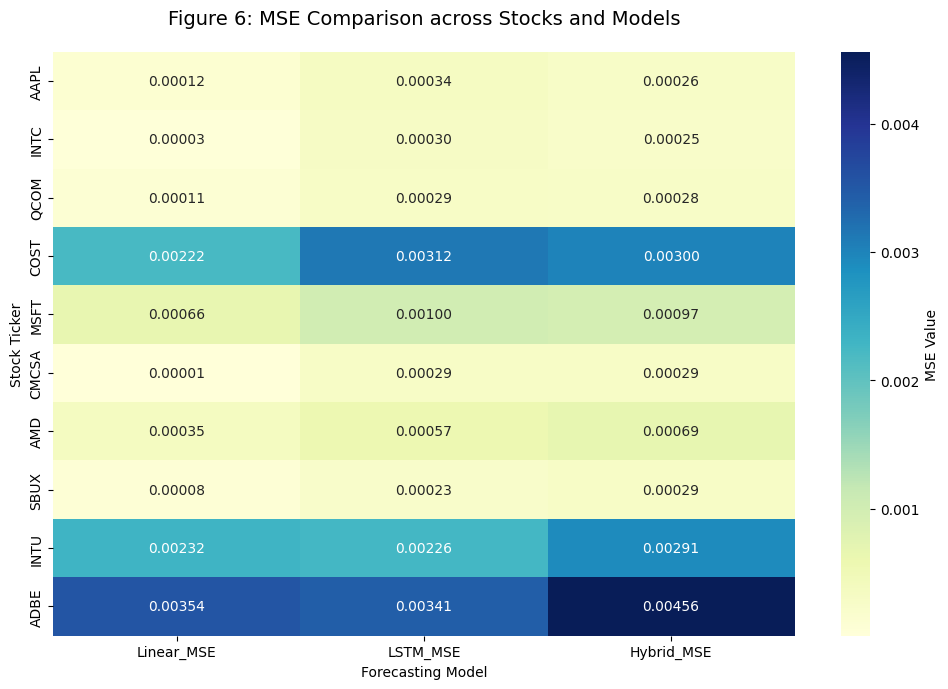

In [23]:
# CELL 24 — Heatmap MSE chuyên nghiệp (Figure 6 Alignment)
import seaborn as sns

# Chuẩn bị dữ liệu cho Heatmap
heatmap_data = stock_mse_df.set_index("Ticker")[["Linear_MSE", "LSTM_MSE", "Hybrid_MSE"]]

plt.figure(figsize=(10, 7))
# Dùng bảng màu YlGnBu (Vàng-Xanh) thường dùng trong báo cáo tài chính
sns.heatmap(heatmap_data, annot=True, fmt=".5f", cmap="YlGnBu", cbar_kws={'label': 'MSE Value'})

plt.title("Figure 6: MSE Comparison across Stocks and Models", fontsize=14, pad=20)
plt.ylabel("Stock Ticker")
plt.xlabel("Forecasting Model")
plt.tight_layout()
plt.show()

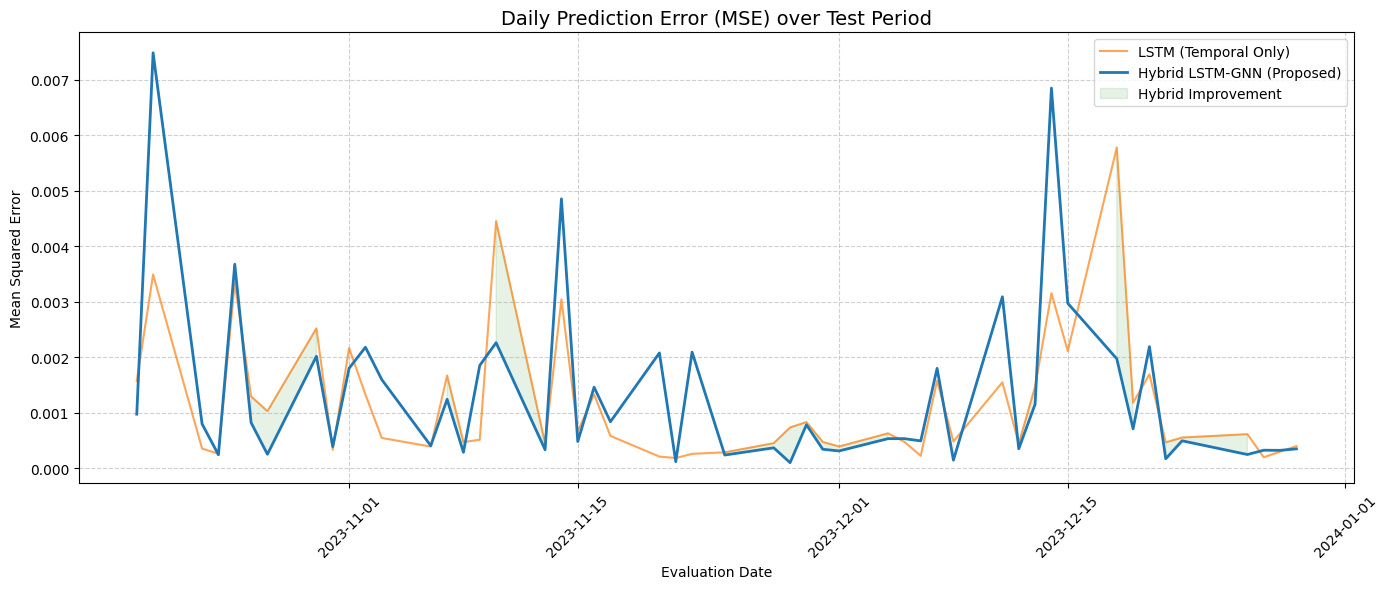

In [24]:
# CELL 25 — Plot lỗi MSE qua chuỗi thời gian Expanding Window
plt.figure(figsize=(14, 6))

# Vẽ đường sai số của LSTM (Baseline)
plt.plot(compare_step_df["Date"], compare_step_df["LSTM_Day_MSE"], 
         label="LSTM (Temporal Only)", color='#ff7f0e', alpha=0.7, linewidth=1.5)

# Vẽ đường sai số của Hybrid (Proposed)
plt.plot(compare_step_df["Date"], compare_step_df["Hybrid_Day_MSE"], 
         label="Hybrid LSTM-GNN (Proposed)", color='#1f77b4', linewidth=2)

# Tô màu vùng chênh lệch để làm nổi bật sự cải thiện
plt.fill_between(compare_step_df["Date"], 
                 compare_step_df["Hybrid_Day_MSE"], 
                 compare_step_df["LSTM_Day_MSE"], 
                 where=(compare_step_df["Hybrid_Day_MSE"] < compare_step_df["LSTM_Day_MSE"]),
                 color='green', alpha=0.1, label='Hybrid Improvement')

plt.title("Daily Prediction Error (MSE) over Test Period", fontsize=14)
plt.xlabel("Evaluation Date")
plt.ylabel("Mean Squared Error")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()